In [2]:
!pip install opencv-python

  Obtaining dependency information for opencv-python from https://files.pythonhosted.org/packages/a4/7d/f1c30a92854540bf789e9cd5dde7ef49bbe63f855b85a2e6b3db8135c591/opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl.metadata
   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.5 MB 325.1 kB/s eta 0:02:02
   ---------------------------------------- 0.1/39.5 MB 465.5 kB/s eta 0:01:25
   ---------------------------------------- 0.1/39.5 MB 774.0 kB/s eta 0:00:51
   ---------------------------------------- 0.3/39.5 MB 1.2 MB/s eta 0:00:33
   ---------------------------------------- 0.4/39.5 MB 1.5 MB/s eta 0:00:26
    --------------------------------------- 0.6/39.5 MB 2.1 MB/s eta 0:00:19
    --------------------------------------- 0.8/39.5 MB 2.3 MB/s eta 0:00:17
   - ------------------

In [3]:
import numpy as np
import cv2
from tensorflow.keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
import os
import zipfile

In [5]:
# Define paths
zip_path = "archive.zip"
extract_path = "/data"

# Extract files
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Verify extraction
os.listdir(extract_path)

['test', 'train']

In [6]:
import os
for root, dirs, files in os.walk("/data"):
    print(root, len(dirs), len(files))


/data 2 0
/data\test 7 0
/data\test\angry 0 958
/data\test\disgust 0 111
/data\test\fear 0 1024
/data\test\happy 0 1774
/data\test\neutral 0 1233
/data\test\sad 0 1247
/data\test\surprise 0 831
/data\train 7 0
/data\train\angry 0 3995
/data\train\disgust 0 436
/data\train\fear 0 4097
/data\train\happy 0 7215
/data\train\neutral 0 4965
/data\train\sad 0 4830
/data\train\surprise 0 3171


In [7]:
train_dir = "/data/train"
val_dir = "/data/test"


In [8]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48,48),
    batch_size=64,
    color_mode="grayscale",
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(48,48),
    batch_size=64,
    color_mode="grayscale",
    class_mode='categorical'
)


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [9]:
emotion_model = Sequential()

emotion_model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(48,48,1)))
emotion_model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
emotion_model.add(MaxPooling2D(pool_size=(2, 2)))
emotion_model.add(Dropout(0.25))

emotion_model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
emotion_model.add(MaxPooling2D(pool_size=(2, 2)))
emotion_model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
emotion_model.add(MaxPooling2D(pool_size=(2, 2)))
emotion_model.add(Dropout(0.25))

emotion_model.add(Flatten())
emotion_model.add(Dense(1024, activation='relu'))
emotion_model.add(Dropout(0.5))
emotion_model.add(Dense(7, activation='softmax'))


C:\Users\kusha\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
cv2.ocl.setUseOpenCL(False)

emotion_model.compile(loss='categorical_crossentropy',
                      optimizer=Adam(learning_rate=0.0001),
                      metrics=['accuracy'])



In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(train_generator.classes),
                                     y=train_generator.classes)
class_weights = dict(enumerate(class_weights))

# Train model with class weights
emotion_model_info = emotion_model.fit(
    train_generator,
    steps_per_epoch=28709 // 64,
    epochs=5,
    validation_data=validation_generator,
    validation_steps=7178 // 64,
    class_weight=class_weights  # Added class weights
)


C:\Users\kusha\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
107/448 ━━━━━━━━━━━━━━━━━━━━ 9:59 2s/step - accuracy: 0.1220 - loss: 1.9592 

In [ ]:
emotion_model.save('newmodel11.h5')

In [ ]:
from google.colab import files

In [ ]:
files.download('newmodel11.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
emotion_dict = {
    0: "Angry", 1: "Disgusted", 2: "Fearful",
    3: "Happy", 4: "Neutral", 5: "Sad", 6: "Surprised"
}


In [ ]:
cap = cv2.VideoCapture(0)
bounding_box = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    num_faces = bounding_box.detectMultiScale(gray_frame, scaleFactor=1.3, minNeighbors=5)

    for (x, y, w, h) in num_faces:
        cv2.rectangle(frame, (x, y-50), (x+w, y+h+10), (255, 0, 0), 2)
        roi_gray_frame = gray_frame[y:y + h, x:x + w]
        cropped_img = np.expand_dims(np.expand_dims(cv2.resize(roi_gray_frame, (48,48)), -1), 0)

        emotion_prediction = emotion_model.predict(cropped_img)
        maxindex = int(np.argmax(emotion_prediction))

        cv2.putText(frame, emotion_dict[maxindex], (x+20, y-60),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)

    cv2.imshow('Video', cv2.resize(frame, (1200,860), interpolation=cv2.INTER_CUBIC))

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━

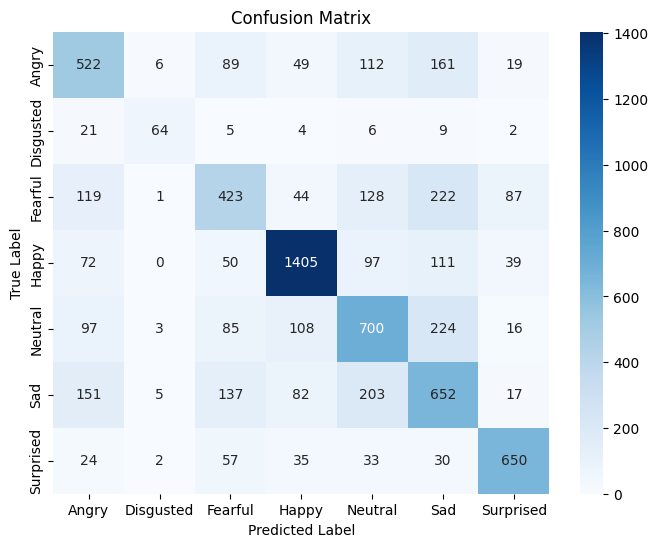

Classification Report:
               precision    recall  f1-score   support

       Angry       0.52      0.54      0.53       958
   Disgusted       0.79      0.58      0.67       111
     Fearful       0.50      0.41      0.45      1024
       Happy       0.81      0.79      0.80      1774
     Neutral       0.55      0.57      0.56      1233
         Sad       0.46      0.52      0.49      1247
   Surprised       0.78      0.78      0.78       831

    accuracy                           0.62      7178
   macro avg       0.63      0.60      0.61      7178
weighted avg       0.62      0.62      0.62      7178



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get true labels and predicted labels
y_true = []
y_pred = []

for i in range(len(validation_generator)):
    X_val, y_val = validation_generator[i]
    y_true.extend(np.argmax(y_val, axis=1))
    y_pred.extend(np.argmax(emotion_model.predict(X_val), axis=1))

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Define emotion labels
emotion_labels = ["Angry", "Disgusted", "Fearful", "Happy", "Neutral", "Sad", "Surprised"]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Print Precision, Recall, and F1-Score
report = classification_report(y_true, y_pred, target_names=emotion_labels)
print("Classification Report:\n", report)


In [ ]:
# Assuming you have a compiled Keras model
# train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
# test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

# print(f"Training Accuracy: {train_acc:.2f}")
# print(f"Test Accuracy: {test_acc:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


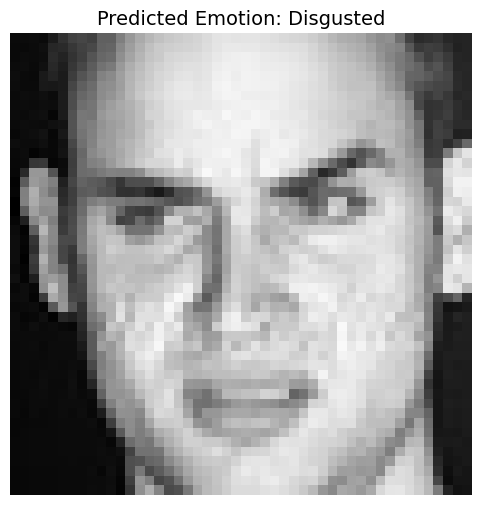

Predicted Emotion: Disgusted


In [ ]:


# Load the trained model weights
emotion_model.load_weights('newmodel11.h5')

# Define emotion labels
emotion_dict = {0: "Angry", 1: "Disgusted", 2: "Fearful", 3: "Happy",
                4: "Neutral", 5: "Sad", 6: "Surprised"}

# Load and preprocess the image
image_path = '/content/data/test/disgust/PrivateTest_4396496.jpg'  # Change this to your image path
image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found!")
else:
    # Convert image to RGB for correct color display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Convert to grayscale for model input
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized_image = cv2.resize(gray_image, (48, 48))  # Resize to model input size
    processed_image = np.expand_dims(np.expand_dims(resized_image, -1), 0)  # Add batch dim

    # Predict emotion
    emotion_prediction = emotion_model.predict(processed_image)
    maxindex = int(np.argmax(emotion_prediction))
    predicted_emotion = emotion_dict[maxindex]

    # Display the image with emotion label
    plt.figure(figsize=(6,6))
    plt.imshow(image_rgb)  # Show the original color image
    plt.axis('off')
    plt.title(f"Predicted Emotion: {predicted_emotion}", fontsize=14)
    plt.show()

    print(f"Predicted Emotion: {predicted_emotion}")
